In [1]:
import sqlite3
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE


In [2]:
# Database path
DB_PATH = "../data/churn.db"

# Connect to SQLite database
conn = sqlite3.connect(DB_PATH)


In [3]:
query = """
SELECT 
    c.customer_id, c.gender, c.senior_citizen, c.partner, c.dependents, c.tenure, c.churn,
    a.contract, a.paperless_billing, a.payment_method, a.monthly_charges, a.total_charges,
    s.phone_service, s.multiple_lines, s.internet_service, s.online_security,
    s.online_backup, s.device_protection, s.tech_support, s.streaming_tv,
    s.streaming_movies
FROM customers c
JOIN accounts a ON c.customer_id = a.customer_id
JOIN services s ON c.customer_id = s.customer_id;
"""

df = pd.read_sql_query(query, conn)
df.head()


,customer_id,gender,senior_citizen,partner,dependents,tenure,churn,contract,paperless_billing,payment_method,...,total_charges,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies
0,3668-QPYBK,Male,0,No,No,2,Yes,Month-to-month,Yes,Mailed check,...,108.15,Yes,No,DSL,Yes,Yes,No,No,No,No
1,9237-HQITU,Female,0,No,Yes,2,Yes,Month-to-month,Yes,Electronic check,...,151.65,Yes,No,Fiber optic,No,No,No,No,No,No
2,9305-CDSKC,Female,0,No,Yes,8,Yes,Month-to-month,Yes,Electronic check,...,820.50,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes
3,7892-POOKP,Female,0,Yes,Yes,28,Yes,Month-to-month,Yes,Electronic check,...,3046.05,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes
4,0280-XJGEX,Male,0,No,Yes,49,Yes,Month-to-month,Yes,Bank transfer (automatic),...,5036.30,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes


In [4]:
# Strip whitespace from all object columns
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype(str).str.strip()


In [5]:
df['churn'] = df['churn'].map({'Yes': 1, 'No': 0})
df['churn'].value_counts()


churn
0    5174
1    1869
Name: count, dtype: int64

In [6]:
# Convert to numeric
df['monthly_charges'] = pd.to_numeric(df['monthly_charges'], errors='coerce')
df['total_charges'] = pd.to_numeric(df['total_charges'], errors='coerce')

# Fill missing values (NO inplace)
df['monthly_charges'] = df['monthly_charges'].fillna(df['monthly_charges'].median())
df['total_charges'] = df['total_charges'].fillna(df['total_charges'].median())


In [7]:
df_model = df.drop(columns=['customer_id'])


In [8]:
cat_cols = df_model.select_dtypes(include='object').columns

df_model = pd.get_dummies(df_model, columns=cat_cols, drop_first=True)
df_model.head()


,senior_citizen,tenure,churn,monthly_charges,total_charges,gender_Male,partner_Yes,dependents_Yes,contract_One year,contract_Two year,...,online_backup_No internet service,online_backup_Yes,device_protection_No internet service,device_protection_Yes,tech_support_No internet service,tech_support_Yes,streaming_tv_No internet service,streaming_tv_Yes,streaming_movies_No internet service,streaming_movies_Yes
0,0,2,1,53.85,108.15,True,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
1,0,2,1,70.70,151.65,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
2,0,8,1,99.65,820.50,False,False,True,False,False,...,False,False,False,True,False,False,False,True,False,True
3,0,28,1,104.80,3046.05,False,True,True,False,False,...,False,False,False,True,False,True,False,True,False,True
4,0,49,1,103.70,5036.30,True,False,True,False,False,...,False,True,False,True,False,False,False,True,False,True


In [9]:
X = df_model.drop('churn', axis=1)
y = df_model['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [10]:
num_cols = ['tenure', 'monthly_charges', 'total_charges']

scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])


In [11]:
smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

X_train_resampled.shape, y_train_resampled.shape


((8278, 30), (8278,))

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)
import matplotlib.pyplot as plt


In [13]:
log_model = LogisticRegression(max_iter=500)

log_model.fit(X_train_resampled, y_train_resampled)

y_pred_log = log_model.predict(X_test)
y_proba_log = log_model.predict_proba(X_test)[:, 1]

log_auc = roc_auc_score(y_test, y_proba_log)

print("Logistic Regression")
print("AUC:", log_auc)
print(confusion_matrix(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))


Logistic Regression
AUC: 0.8291689271228914
[[786 249]
 [107 267]]
              precision    recall  f1-score   support

           0       0.88      0.76      0.82      1035
           1       0.52      0.71      0.60       374

    accuracy                           0.75      1409
   macro avg       0.70      0.74      0.71      1409
weighted avg       0.78      0.75      0.76      1409



In [14]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_resampled, y_train_resampled)

y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

rf_auc = roc_auc_score(y_test, y_proba_rf)

print("Random Forest")
print("AUC:", rf_auc)
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


Random Forest
AUC: 0.8457516339869281
[[800 235]
 [ 96 278]]
              precision    recall  f1-score   support

           0       0.89      0.77      0.83      1035
           1       0.54      0.74      0.63       374

    accuracy                           0.77      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.77      0.78      1409



In [15]:
pip install xgboost


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [16]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train_resampled, y_train_resampled)

y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

xgb_auc = roc_auc_score(y_test, y_proba_xgb)

print("XGBoost")
print("AUC:", xgb_auc)
print(confusion_matrix(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))


XGBoost
AUC: 0.834674106796869
[[824 211]
 [117 257]]
              precision    recall  f1-score   support

           0       0.88      0.80      0.83      1035
           1       0.55      0.69      0.61       374

    accuracy                           0.77      1409
   macro avg       0.71      0.74      0.72      1409
weighted avg       0.79      0.77      0.77      1409



In [17]:
auc_scores = {
    "Logistic Regression": log_auc,
    "Random Forest": rf_auc,
    "XGBoost": xgb_auc
}

auc_scores


{'Logistic Regression': np.float64(0.8291689271228914),
 'Random Forest': np.float64(0.8457516339869281),
 'XGBoost': np.float64(0.834674106796869)}

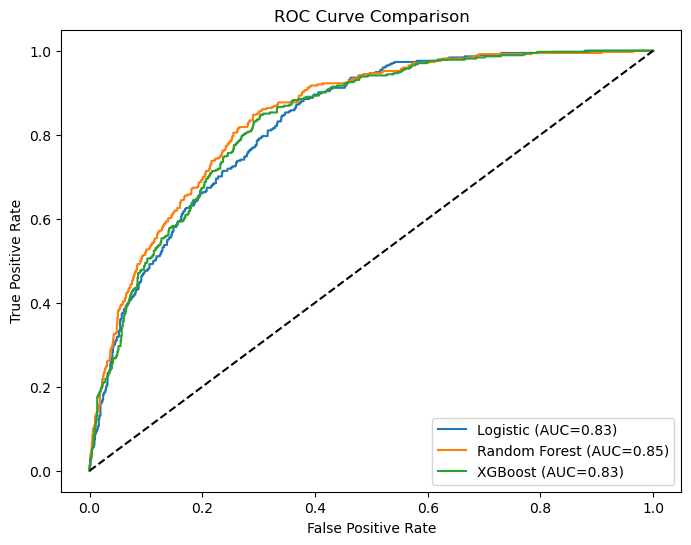

In [18]:
plt.figure(figsize=(8,6))

fpr_log, tpr_log, _ = roc_curve(y_test, y_proba_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)

plt.plot(fpr_log, tpr_log, label=f"Logistic (AUC={log_auc:.2f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC={rf_auc:.2f})")
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC={xgb_auc:.2f})")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()


📌 Model Selection Summary

   Logistic Regression used as baseline model

   Random Forest achieved the highest AUC score (0.846)

   XGBoost performed well but slightly lower than Random Forest

   Final selected model: Random Forest Classifier

Reason for selection:

   Best AUC score

   Strong recall for churn customers

   Handles non-linear relationships

   More stable and interpretable

In [19]:
import joblib
import os

# Create models directory if not exists
os.makedirs("../models", exist_ok=True)

# Save best model (Random Forest)
joblib.dump(rf_model, "../models/churn_model.pkl")

# Save scaler
joblib.dump(scaler, "../models/scaler.pkl")

# Save feature columns (important for Streamlit)
joblib.dump(X_train.columns.tolist(), "../models/feature_columns.pkl")

print("Model, scaler, and feature columns saved successfully.")


Model, scaler, and feature columns saved successfully.
